# Data Preprocessing

Firstly, we import the 'pandas' library and our CSV file, turning it into a dataframe.

In [53]:
import pandas as pd

df = pd.read_csv("uv_Gaithersburg_USA_csv.csv", sep=',')
df

,YYYYMMDD,UVIEF,UVIEFerr,UVDEF,UVDEFerr,UVDEC,UVDECerr,UVDVF,UVDVFerr,UVDVC,UVDVCerr,UVDDF,UVDDFerr,UVDDC,UVDDCerr,CMF,ozone
0,20020701,9.348,0.519,5.263,0.337,-1.0,-1.0,9.831,0.833,-1.0,-1.0,2.785,0.283,-1.0,-1.0,-1.0,318.6
1,20020702,9.821,0.519,5.513,0.336,-1.0,-1.0,10.412,0.832,-1.0,-1.0,3.029,0.283,-1.0,-1.0,-1.0,307.2
2,20020703,8.325,0.518,4.711,0.335,-1.0,-1.0,8.560,0.831,-1.0,-1.0,2.281,0.282,-1.0,-1.0,-1.0,346.4
3,20020704,8.874,0.518,5.001,0.335,-1.0,-1.0,9.234,0.830,-1.0,-1.0,2.547,0.282,-1.0,-1.0,-1.0,330.2
4,20020705,8.847,0.518,4.984,0.335,-1.0,-1.0,9.196,0.829,-1.0,-1.0,2.533,0.282,-1.0,-1.0,-1.0,330.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8664,20260321,4.906,0.354,2.408,0.196,-1.0,-1.0,4.040,0.483,-1.0,-1.0,0.948,0.165,-1.0,-1.0,-1.0,342.6
8665,20260322,5.569,0.357,2.720,0.198,-1.0,-1.0,4.739,0.490,-1.0,-1.0,1.183,0.167,-1.0,-1.0,-1.0,314.0
8666,20260323,5.186,0.361,2.553,0.201,-1.0,-1.0,4.341,0.496,-1.0,-1.0,1.039,0.170,-1.0,-1.0,-1.0,335.5
8667,20260324,4.677,0.365,2.326,0.204,-1.0,-1.0,3.811,0.503,-1.0,-1.0,0.860,0.172,-1.0,-1.0,-1.0,368.1


Next is to handle types. The dates are already organized as YYYYMMDD, which is useful. We convert them to datetime objects for easier handling later. All other values are floats, so they do not need to be cleaned.

In [54]:
# Convert YYYYMMDD column into a string, then into a datetime object
df['YYYYMMDD'] = df['YYYYMMDD'].astype(str)
df['YYYYMMDD'] = pd.to_datetime(df['YYYYMMDD'], format='%Y%m%d')
#df['YYYYMMDD'] = df['YYYYMMDD'].dt.strftime('%Y-%m-%d')

This data set uses -1 to represent missing data. We convert all -1 values into NA values that pandas properly treats as missing data.

In [55]:
df.replace(-1, pd.NA)

,YYYYMMDD,UVIEF,UVIEFerr,UVDEF,UVDEFerr,UVDEC,UVDECerr,UVDVF,UVDVFerr,UVDVC,UVDVCerr,UVDDF,UVDDFerr,UVDDC,UVDDCerr,CMF,ozone
0,2002-07-01,9.348,0.519,5.263,0.337,<NA>,<NA>,9.831,0.833,<NA>,<NA>,2.785,0.283,<NA>,<NA>,<NA>,318.6
1,2002-07-02,9.821,0.519,5.513,0.336,<NA>,<NA>,10.412,0.832,<NA>,<NA>,3.029,0.283,<NA>,<NA>,<NA>,307.2
2,2002-07-03,8.325,0.518,4.711,0.335,<NA>,<NA>,8.560,0.831,<NA>,<NA>,2.281,0.282,<NA>,<NA>,<NA>,346.4
3,2002-07-04,8.874,0.518,5.001,0.335,<NA>,<NA>,9.234,0.830,<NA>,<NA>,2.547,0.282,<NA>,<NA>,<NA>,330.2
4,2002-07-05,8.847,0.518,4.984,0.335,<NA>,<NA>,9.196,0.829,<NA>,<NA>,2.533,0.282,<NA>,<NA>,<NA>,330.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8664,2026-03-21,4.906,0.354,2.408,0.196,<NA>,<NA>,4.040,0.483,<NA>,<NA>,0.948,0.165,<NA>,<NA>,<NA>,342.6
8665,2026-03-22,5.569,0.357,2.720,0.198,<NA>,<NA>,4.739,0.490,<NA>,<NA>,1.183,0.167,<NA>,<NA>,<NA>,314.0
8666,2026-03-23,5.186,0.361,2.553,0.201,<NA>,<NA>,4.341,0.496,<NA>,<NA>,1.039,0.170,<NA>,<NA>,<NA>,335.5
8667,2026-03-24,4.677,0.365,2.326,0.204,<NA>,<NA>,3.811,0.503,<NA>,<NA>,0.860,0.172,<NA>,<NA>,<NA>,368.1


We observe that there are a high amount of missing values for the data columns that are "cloud-modified". In fact, these are the only columns in the entire dataset with missing data:

In [56]:
df[['YYYYMMDD', 'UVIEF', 'UVIEFerr', 'UVDEF', 'UVDEFerr', 'UVDVF', 'UVDVFerr', 'UVDDF',
    'UVDDFerr', 'ozone']].isna().sum().sum()

0

As such, for all further data processing and analysis, we will only be considering the "cloud-free" values. We can safely drop the unused columns.  

In [57]:
df = df.drop(['UVDEC', 'UVDECerr', 'UVDVC', 'UVDVCerr', 'UVDDC', 'UVDDCerr', 'CMF',], axis=1, errors="ignore")
df

,YYYYMMDD,UVIEF,UVIEFerr,UVDEF,UVDEFerr,UVDVF,UVDVFerr,UVDDF,UVDDFerr,ozone
0,2002-07-01,9.348,0.519,5.263,0.337,9.831,0.833,2.785,0.283,318.6
1,2002-07-02,9.821,0.519,5.513,0.336,10.412,0.832,3.029,0.283,307.2
2,2002-07-03,8.325,0.518,4.711,0.335,8.560,0.831,2.281,0.282,346.4
3,2002-07-04,8.874,0.518,5.001,0.335,9.234,0.830,2.547,0.282,330.2
4,2002-07-05,8.847,0.518,4.984,0.335,9.196,0.829,2.533,0.282,330.6
...,...,...,...,...,...,...,...,...,...,...
8664,2026-03-21,4.906,0.354,2.408,0.196,4.040,0.483,0.948,0.165,342.6
8665,2026-03-22,5.569,0.357,2.720,0.198,4.739,0.490,1.183,0.167,314.0
8666,2026-03-23,5.186,0.361,2.553,0.201,4.341,0.496,1.039,0.170,335.5
8667,2026-03-24,4.677,0.365,2.326,0.204,3.811,0.503,0.860,0.172,368.1


# Exploratory Data Analysis

Now that we've gotten the data cleaning out of the way, it's time to make some preliminary hypotheses that will shape the rest of our efforts with this data set.

They are:  
1) Intensity of erythemal UV dose is increased in summer months (June, July, August).  
2) Average intensity of erythemal UV index has increased from 2003 to 2025.  
3) There is a positive correlation between the Vitamin D UV dose and the DNA-damage UV dose.  

### Hypothesis 1

$H_0$: The summer months do not have a higher erythemal UV dose compared to the other seasons.  
$H_a$: The summer months have a higher erythemal UV dose than the other seasons.

First, since our hypothesis is based on seasonal relationships, we can split our values into their respective months.

In [58]:
hypo1_df = df

def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

hypo1_df['season'] = hypo1_df['YYYYMMDD'].dt.month.apply(get_season)
hypo1_df = hypo1_df.reindex(columns=['YYYYMMDD', 'season', 'UVIEF', 'UVIEFerr', 'UVDEF', 'UVDEFerr', 'UVDVF',
       'UVDVFerr', 'UVDDF', 'UVDDFerr', 'ozone'])
hypo1_df

,YYYYMMDD,season,UVIEF,UVIEFerr,UVDEF,UVDEFerr,UVDVF,UVDVFerr,UVDDF,UVDDFerr,ozone
0,2002-07-01,Summer,9.348,0.519,5.263,0.337,9.831,0.833,2.785,0.283,318.6
1,2002-07-02,Summer,9.821,0.519,5.513,0.336,10.412,0.832,3.029,0.283,307.2
2,2002-07-03,Summer,8.325,0.518,4.711,0.335,8.560,0.831,2.281,0.282,346.4
3,2002-07-04,Summer,8.874,0.518,5.001,0.335,9.234,0.830,2.547,0.282,330.2
4,2002-07-05,Summer,8.847,0.518,4.984,0.335,9.196,0.829,2.533,0.282,330.6
...,...,...,...,...,...,...,...,...,...,...,...
8664,2026-03-21,Spring,4.906,0.354,2.408,0.196,4.040,0.483,0.948,0.165,342.6
8665,2026-03-22,Spring,5.569,0.357,2.720,0.198,4.739,0.490,1.183,0.167,314.0
8666,2026-03-23,Spring,5.186,0.361,2.553,0.201,4.341,0.496,1.039,0.170,335.5
8667,2026-03-24,Spring,4.677,0.365,2.326,0.204,3.811,0.503,0.860,0.172,368.1


Next, we'll group by season, plot our results, and apply our tests. We will use a significance value of 0.05.

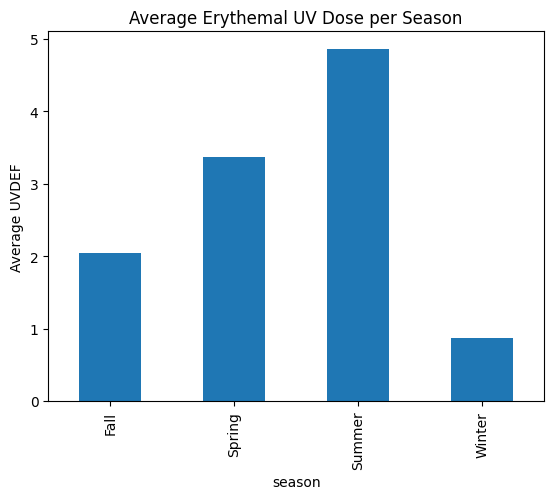

In [59]:
import matplotlib.pyplot as plt

hypo1_df.groupby("season")["UVDEF"].mean().plot(kind="bar")
plt.ylabel("Average UVDEF")
plt.title("Average Erythemal UV Dose per Season")
plt.show()

In [60]:
from scipy import stats

groups = [group["UVDEF"].values for _, group in hypo1_df.groupby("season")]
stats.f_oneway(*groups)

F_onewayResult(statistic=10808.425438483986, pvalue=0.0)

Our p-value is so close to 0 that scipy is simply treating it as 0. Thus, one of our seasons is meaningfully different from the others. Let us observe where the differences lie:

In [61]:
from scipy.stats import tukey_hsd

result = tukey_hsd(*groups).pvalue
display(result)

array([[1.00000000e+00, 7.32036654e-12, 7.32036654e-12, 7.32036654e-12],
       [7.32036654e-12, 1.00000000e+00, 7.32036654e-12, 7.32036654e-12],
       [7.32036654e-12, 7.32036654e-12, 1.00000000e+00, 7.32036654e-12],
       [7.32036654e-12, 7.32036654e-12, 7.32036654e-12, 1.00000000e+00]])

Our processing indicates that not only is summer different from the other seasons, but ALL seasons are meaningfully different from one another. Thus we can reject the null hypothesis and conclude that summer does have a higher erythemal UV dose than the other seasons.

<br> <!-- to make space -->

### Hypothesis 2

$H_0$: The average annual UV index has not increased over time.  
$H_a$: The average annual UV index has increased over time.

This time, we want to group our values by year. Since the years 2002 and 2026 are not complete (2002 starts in July and 2026 only goes to March), we will drop those years and only consider 2003-2025.

In [62]:
hypo2_df = df

hypo2_df["year"] = hypo2_df["YYYYMMDD"].dt.year
hypo2_df = hypo2_df[~hypo2_df["year"].isin([2002, 2026])]
hypo2_df

,YYYYMMDD,UVIEF,UVIEFerr,UVDEF,UVDEFerr,UVDVF,UVDVFerr,UVDDF,UVDDFerr,ozone,season,year
184,2003-01-01,1.430,0.133,0.600,0.062,0.785,0.148,0.152,0.052,322.5,Winter,2003
185,2003-01-02,1.501,0.134,0.627,0.062,0.842,0.149,0.166,0.053,310.1,Winter,2003
186,2003-01-03,1.311,0.135,0.556,0.062,0.685,0.150,0.128,0.053,356.2,Winter,2003
187,2003-01-04,1.382,0.136,0.584,0.063,0.742,0.151,0.141,0.053,340.6,Winter,2003
188,2003-01-05,1.245,0.136,0.533,0.063,0.628,0.152,0.114,0.054,382.0,Winter,2003
...,...,...,...,...,...,...,...,...,...,...,...,...
8580,2025-12-27,1.558,0.131,0.645,0.061,0.891,0.145,0.180,0.051,291.6,Winter,2025
8581,2025-12-28,1.621,0.131,0.669,0.061,0.943,0.146,0.194,0.052,282.3,Winter,2025
8582,2025-12-29,1.609,0.132,0.665,0.061,0.933,0.146,0.191,0.052,285.4,Winter,2025
8583,2025-12-30,1.168,0.132,0.500,0.061,0.570,0.147,0.102,0.052,392.9,Winter,2025


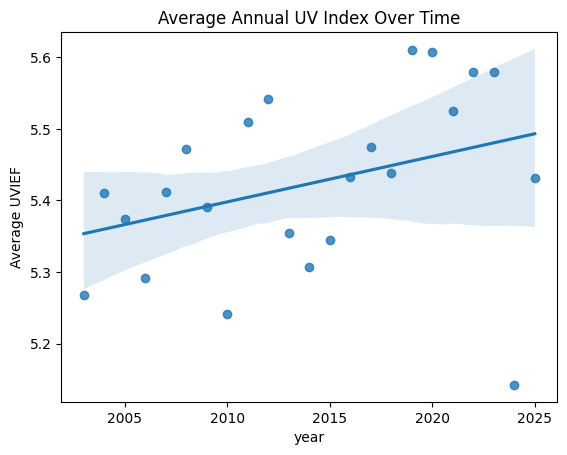

In [63]:
import seaborn as sns

yearly_uv = hypo2_df.groupby("year")["UVIEF"].mean().reset_index()
sns.regplot(x="year", y="UVIEF", data=yearly_uv, ci=95)
plt.title("Average Annual UV Index Over Time")
plt.ylabel("Average UVIEF")
plt.show()

There seems to be a small upward trend, but 2024 appears to be an outlier. We will remove it and do a linear regression test on what remains to see if our slope is significant enough:

In [68]:
from scipy.stats import linregress

no2024_df = hypo2_df[~hypo2_df["year"].isin([2024])]
yearly_uv_repaired = no2024_df.groupby("year")["UVIEF"].mean().reset_index()
result = linregress(yearly_uv_repaired["year"], yearly_uv_repaired["UVIEF"], alternative="greater")

display(result.pvalue)

0.001108015031169088

Indeed, with a p-value of $0.0011 < 0.05$, we can safely reject the null and conclude that the average annual UV index has increased from 2003 to 2025.

<br> <!-- to make space -->

### Hypothesis 3

$H_0$: There is not a positive correlation between Vitamin D dose and DNA damage dose.  
$H_a$: There is a positive correlation between Vitamin D dose and DNA damage dose.

In [65]:

# this is blank space















TEMIS v2.0 UV index and UV dose overpass file  
------------------------------------------------  
http://www.temis.nl/uvradiation/UVarchive.html  
 
Station name     = Gaithersburg  
Station country  = USA  
Station lon, lat = -77.20, 39.10  

Grid cell size              = 0.25 x 0.25 degrees  
Grid cell centre lon, lat   = -77.125, 39.125  
Grid cell average elevation = 130 (+/- 25) m  
Grid cell within MSG area   = no  

Data columns:  
    1 = YYYYMMDD        : date string  
    2, 3 = UVIEF, UVIEFerr : cloud-free erythemal UV index      [-]  
    4, 5 = UVDEF, UVDEFerr : cloud-free     erythemal  UV dose  [kJ/m2]   
    6, 7 = UVDEC, UVDECerr : cloud-modified erythemal  UV dose  [kJ/m2]  
    8, 9 = UVDVF, UVDVFerr : cloud-free     vitamin-D  UV dose  [kJ/m2]  
    10,11 = UVDVC, UVDVCerr : cloud-modified vitamin-D  UV dose  [kJ/m2]  
    12,13 = UVDDF, UVDDFerr : cloud-free     dna-damage UV dose  [kJ/m2]  
    14,15 = UVDDC, UVDDCerr : cloud-modified dna-damage UV dose  [kJ/m2]  
    16 = CMF             : average cloud modification factor  [-]  
    17 = ozone           : local solar noon ozone column      [DU]  
    
No-data entry = -1.000  

kJ/m2 = Kilojoules per square meter  

Erythemal Ultraviolet:  
UV radiation (295-325 nm) that generally causes skin reddening and sunburn  

Vitamin-D Ultraviolet:  
Synthesis of vitamin D in the skin from UV radiation

DNA-damage Ultraviolet dose:  
UV radiation causes photolesions in the DNA, which damage and mutate DNA  

In [66]:
from scipy.stats import tukey_hsd

result = tukey_hsd(*groups).pvalue
display(result)

array([[1.00000000e+00, 7.32036654e-12, 7.32036654e-12, 7.32036654e-12],
       [7.32036654e-12, 1.00000000e+00, 7.32036654e-12, 7.32036654e-12],
       [7.32036654e-12, 7.32036654e-12, 1.00000000e+00, 7.32036654e-12],
       [7.32036654e-12, 7.32036654e-12, 7.32036654e-12, 1.00000000e+00]])